# 10 · Uplift evaluation & policy — from $\hat\tau(x)$ to a decision you can trust

**NB 10.** NB 09 estimated *who* responds; here we turn $\hat\tau(x)$ into a **policy** and ask the two
questions that matter: **(a) is the targeting any good?** (Qini / AUUC / **RATE**) and **(b) what is the
policy worth?** (policy value via **off-policy evaluation** — IPS / DR). Because we author the DGP we know
the *true* $\tau(x)$, so we **validate** that OPE recovers the true policy value and that RATE detects real
heterogeneity — the superpower, applied to decisions. The unifying tool is the **doubly-robust score**.
Backs: GRF/RATE (Yadlowsky et al.), Dudík DR policy eval, Athey–Wager policy learning, Künzel→NB 09.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor as GBR
from sklearn.model_selection import KFold
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))

import nbtools; nbtools.set_style()
from nbtools import BLUE, GREEN, PINK, ORANGE, GRAY
from lyra.dgp import HeteroDGP
from lyra.cate import XLearner

H = HeteroDGP(seed=1)
XC = [f"x{j}" for j in range(5)]
tr = H.sample(8000, seed=1)
te = H.sample(8000, seed=7)
Xte, T, y = te[XC].to_numpy(), te["treat"].to_numpy(), te["y"].to_numpy()
tau_true = H.tau(Xte)                                    # the oracle (we authored it)
tau_hat = XLearner().fit(tr).predict_cate(Xte)          # the CATE model from NB 09
E = 0.5                                                  # known propensity (RCT)
print(f"ATE = {tau_true.mean():+.3f}   |   τ(x) spans {tau_true.min():+.2f} … {tau_true.max():+.2f}")

ATE = +0.495   |   τ(x) spans -4.70 … +4.71


## 1. The doubly-robust score — one tool for everything

Cross-fit per-arm outcome models $\hat\mu_1,\hat\mu_0$ and form the **AIPW / DR pseudo-outcome**
$$\Gamma_i=\hat\mu_1(x_i)-\hat\mu_0(x_i)+\frac{T_i}{e}\big(y_i-\hat\mu_1\big)-\frac{1-T_i}{1-e}\big(y_i-\hat\mu_0\big).$$
$\Gamma_i$ is an **unbiased per-unit estimate of $\tau_i$** (robust to a wrong outcome model when $e$ is
known). Its mean is the AIPW **ATE**; weighting it by a policy gives the **policy value**; ranking by
$\hat\tau$ and cumulating it gives the **uplift curve**. Everything below is built from $\Gamma$.

In [2]:
def dr_scores(X, T, y, e=0.5, seed=0):
    mu1 = np.zeros(len(y)); mu0 = np.zeros(len(y))
    for tr_i, te_i in KFold(4, shuffle=True, random_state=seed).split(X):
        for arm, mu in ((1, mu1), (0, mu0)):
            sel = tr_i[T[tr_i] == arm]
            mu[te_i] = GBR().fit(X[sel], y[sel]).predict(X[te_i])
    return mu1 - mu0 + T / e * (y - mu1) - (1 - T) / (1 - e) * (y - mu0)

G = dr_scores(Xte, T, y, e=E)
print(f"AIPW ATE = mean(Γ) = {G.mean():+.3f}   (truth {tau_true.mean():+.3f})   corr(Γ, τ_true) = {np.corrcoef(G, tau_true)[0,1]:.2f}")

AIPW ATE = mean(Γ) = +0.486   (truth +0.495)   corr(Γ, τ_true) = 0.48


## 2. The uplift curve (TOC) & AUUC — is the ranking any good?

Sort by $\hat\tau$ (best first); for each depth $q$ plot the **average effect of the top-$q$ fraction**.
A useful score starts **high** (the model finds the responders) and decays to the ATE at $q=1$. We
compare the **model** (rank by $\hat\tau$) to the **oracle** (rank by true $\tau$, the ceiling) and to
**random** (flat at the ATE). The gap above random, integrated, is the **AUUC**.

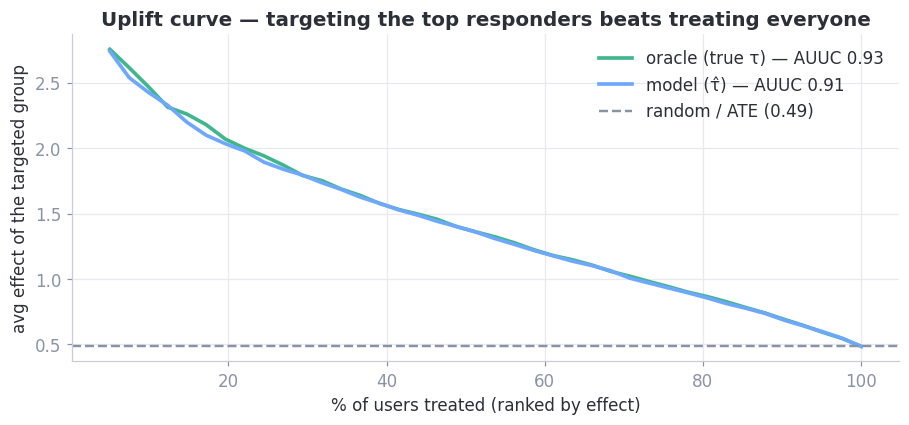

In [3]:
def uplift_curve(score, rank, qs):
    order = np.argsort(-rank)
    return np.array([score[order[: max(1, int(q * len(score)))]].mean() for q in qs])

qs = np.linspace(0.05, 1.0, 40)
curve_model = uplift_curve(G, tau_hat, qs)
curve_oracle = uplift_curve(G, tau_true, qs)
auuc = np.mean(curve_model - G.mean()); auuc_or = np.mean(curve_oracle - G.mean())

fig, ax = plt.subplots(figsize=(8.4, 4))
ax.plot(qs * 100, curve_oracle, color=GREEN, lw=2.4, label=f"oracle (true τ) — AUUC {auuc_or:.2f}")
ax.plot(qs * 100, curve_model, color=BLUE, lw=2.4, label=f"model (τ̂) — AUUC {auuc:.2f}")
ax.axhline(G.mean(), color=GRAY, ls="--", lw=1.6, label=f"random / ATE ({G.mean():.2f})")
ax.set_xlabel("% of users treated (ranked by effect)"); ax.set_ylabel("avg effect of the targeted group")
ax.set_title("Uplift curve — targeting the top responders beats treating everyone"); ax.legend()
plt.tight_layout(); plt.show()

## 3. RATE — *is the heterogeneity real?* (with a CI)

**RATE** (the area between the uplift curve and the ATE line — AUTOC) summarizes targeting value in one
number, and because it's a mean of i.i.d. unit contributions it comes with a **standard error** → a
hypothesis test of $H_0$: *no exploitable heterogeneity*.

In [4]:
def rate_autoc(G, rank, qs):
    order = np.argsort(-rank); n = len(G); gbar = G.mean()
    return float(np.mean([G[order[: max(1, int(q * n))]].mean() - gbar for q in qs]))

def rate_with_ci(G, rank, qs, B=300, seed=0):
    rate = rate_autoc(G, rank, qs)
    rng = np.random.default_rng(seed); n = len(G)
    boots = [rate_autoc(G[i], rank[i], qs) for i in (rng.integers(0, n, n) for _ in range(B))]
    return rate, float(np.std(boots, ddof=1))

rate, se = rate_with_ci(G, tau_hat, qs)
z = rate / se
print(f"RATE = {rate:.3f} ± {1.96*se:.3f}   (z = {z:.1f})  →  "
      f"{'heterogeneity is real and targetable' if z > 1.96 else 'no significant heterogeneity'}")

RATE = 0.913 ± 0.043   (z = 42.0)  →  heterogeneity is real and targetable


## 4. Policy learning — a rule you can deploy

A **policy** $\pi(x)\in\{0,1\}$. With a treatment **cost** $c$, treat iff the benefit beats it,
$\pi(x)=\mathbb 1\{\hat\tau(x)>c\}$. We also fit an **interpretable policy tree** (econml `DRPolicyTree`)
— a shallow, auditable rule. The **value** of a policy is $V(\pi)=\mathbb E[\pi(X)\,\Gamma]$ (DR), which
we can check against the **truth** $\mathbb E[\pi(X)\,\tau(X)]$.

In [5]:
COST = 0.3
pi_thresh = (tau_hat > COST).astype(int)

def value_dr(pi, G, cost=0.0):                          # DR estimate of the policy's net value
    return float((pi * (G - cost)).mean())
def value_true(pi, tau, cost=0.0):
    return float((pi * (tau - cost)).mean())

from econml.policy import DRPolicyTree
tree = DRPolicyTree(max_depth=2, min_samples_leaf=200, random_state=0).fit(y, T, X=Xte)
pi_tree = (tree.predict(Xte) == 1).astype(int) if tree.predict(Xte).ndim == 1 else np.argmax(tree.predict(Xte), 1)

for name, pi in [("treat everyone", np.ones(len(y), int)), ("threshold τ̂>c", pi_thresh), ("policy tree", pi_tree)]:
    print(f"  {name:<16} treats {pi.mean():4.0%}  net value: DR {value_dr(pi, G, COST):+.3f}  vs truth {value_true(pi, tau_true, COST):+.3f}")
print(f"  (cost c = {COST}; treating everyone wastes spend on the {np.mean(tau_true < COST):.0%} below cost)")

  treat everyone   treats 100%  net value: DR +0.186  vs truth +0.195
  threshold τ̂>c   treats  56%  net value: DR +0.543  vs truth +0.544
  policy tree      treats  67%  net value: DR +0.495  vs truth +0.498
  (cost c = 0.3; treating everyone wastes spend on the 43% below cost)


Targeting **beats treat-everyone net of cost** — and the DR value tracks the true value, so we'd trust it
without the oracle. The policy tree gives a deployable, auditable rule at a small value cost vs the raw
threshold.

## 5. Off-policy evaluation — recover the value *without* re-running

The point of OPE: estimate $V(\pi)$ for a *new* policy from already-logged data. **IPS** is unbiased but
high-variance; **DR** adds the outcome model as a control variate → far tighter. We validate both recover
the **true** value of the threshold policy.

true V(π: τ̂>0)      = +0.730
IPS  estimate        = +0.742  ± 0.051  (SD over runs)
DR   estimate        = +0.736  ± 0.031  ← unbiased & ~2× tighter


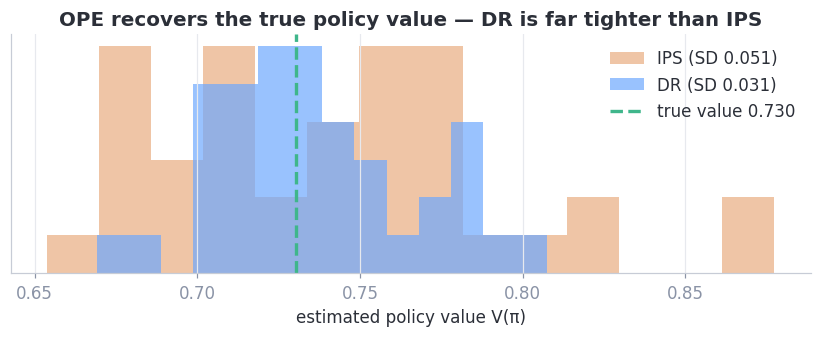

In [6]:
def value_ips(pi, X, T, y, e=0.5):
    return float((pi * (T / e - (1 - T) / (1 - e)) * y).mean())

model = XLearner().fit(tr)                               # one fixed policy; evaluate it on fresh logs
ips_est, dr_est = [], []
for s in range(40):
    d = H.sample(4000, seed=100 + s)
    Xd, Td, yd = d[XC].to_numpy(), d["treat"].to_numpy(), d["y"].to_numpy()
    pid = (model.predict_cate(Xd) > 0).astype(int)
    Gd = dr_scores(Xd, Td, yd, e=E)
    ips_est.append(value_ips(pid, Xd, Td, yd)); dr_est.append(value_dr(pid, Gd))
truth = value_true((tau_hat > 0).astype(int), tau_true)
print(f"true V(π: τ̂>0)      = {truth:+.3f}")
print(f"IPS  estimate        = {np.mean(ips_est):+.3f}  ± {np.std(ips_est):.3f}  (SD over runs)")
print(f"DR   estimate        = {np.mean(dr_est):+.3f}  ± {np.std(dr_est):.3f}  ← unbiased & ~{np.std(ips_est)/np.std(dr_est):.0f}× tighter")

fig, ax = plt.subplots(figsize=(7.6, 3.2))
ax.hist(ips_est, bins=14, alpha=0.5, color=ORANGE, label=f"IPS (SD {np.std(ips_est):.3f})")
ax.hist(dr_est, bins=14, alpha=0.7, color=BLUE, label=f"DR (SD {np.std(dr_est):.3f})")
ax.axvline(truth, color=GREEN, ls="--", lw=2.2, label=f"true value {truth:.3f}")
ax.set_xlabel("estimated policy value V(π)"); ax.set_yticks([]); ax.set_title("OPE recovers the true policy value — DR is far tighter than IPS"); ax.legend()
plt.tight_layout(); plt.show()

## 6. Promote → `lyra/{policy,ope}.py`

Promoted: `lyra/policy.py` (`dr_scores`, `uplift_curve`, `auuc`, `rate`, `threshold_policy`,
`policy_value`) and `lyra/ope.py` (`ips_value`, `dr_value`). `tests/test_policy.py` asserts RATE detects
the (real) heterogeneity, targeting beats treat-all on true value, and DR-OPE recovers the true policy
value with lower variance than IPS. **Next (`ROADMAP.md`): NB 11 — observational** (DML · modern DiD ·
synthetic control · IV/LATE) — causal effects *without* randomization.

In [7]:
from lyra.policy import rate as lyra_rate, threshold_policy, policy_value
from lyra.ope import dr_value, ips_value
G2 = dr_scores(Xte, T, y, e=E)
print("promoted rate:", round(lyra_rate(G2, tau_hat)[0], 3),
      "| DR value of τ̂>0:", round(dr_value(threshold_policy(tau_hat, 0.0), G2), 3),
      "(truth", round(value_true((tau_hat > 0).astype(int), tau_true), 3), ")")

promoted rate: 0.912 | DR value of τ̂>0: 0.728 (truth 0.73 )
